<a href="https://colab.research.google.com/github/LennardBehmann/Intro-ML/blob/main/Homework_4/ML_HW4_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4 Problem 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

2.1 Load cancer dataset and display

In [2]:
url = 'https://raw.githubusercontent.com/LennardBehmann/Intro-ML/refs/heads/main/Homework_4/Housing.csv'

df = pd.read_csv(url)

display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


2.2 Inpect Dataset

In [3]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (545, 13)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Summary statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


2.3 Define X and y

In [4]:
X = df.drop(['price','furnishingstatus'], axis=1)
y=df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X)
display(y)

X shape: (545, 11)
y shape: (545,)


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,yes,no,no,no,yes,2,yes
1,8960,4,4,4,yes,no,no,no,yes,3,no
2,9960,3,2,2,yes,no,yes,no,no,2,yes
3,7500,4,2,2,yes,no,yes,no,yes,3,yes
4,7420,4,1,2,yes,yes,yes,no,yes,2,no
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no
541,2400,3,1,1,no,no,no,no,no,0,no
542,3620,2,1,1,yes,no,no,no,no,0,no
543,2910,3,1,1,no,no,no,no,no,0,no


,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


2.4 Encode yes/no feataurs

In [5]:
features = ['area','bedrooms','bathrooms','stories','mainroad','guestroom','basement','hotwaterheating','airconditioning','parking','prefarea']

X = df[features].copy()

binary_features = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

X[binary_features] = X[binary_features].apply(
    lambda col: col.map({'no': 0, 'yes': 1})
)

display(X.head())

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,1,0,0,0,1,2,1
1,8960,4,4,4,1,0,0,0,1,3,0
2,9960,3,2,2,1,0,1,0,0,2,1
3,7500,4,2,2,1,0,1,0,1,3,1
4,7420,4,1,2,1,1,1,0,1,2,0


2.5 80/20 Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (436, 11)
X_test shape: (109, 11)
y_train shape: (436,)
y_test shape: (109,)


2.6 Standardise

In [7]:
# Scale input features
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Scale target values for SVR training
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

2.7 Train First SVR

In [8]:
# Create linear SVR model
svr_linear = SVR(
    kernel='linear',
    C=1.0,
    epsilon=0.1
)

# Train the model
svr_linear.fit(X_train_scaled, y_train_scaled)

# Predict scaled target values
y_pred_scaled = svr_linear.predict(X_test_scaled)

# Transform predictions back to original price scale
y_pred_linear = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

2.8 Evaluate First SVR

In [9]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"R²:   {r2_linear:.4f}")
print(f"MAE:  {mae_linear:,.2f}")
print(f"RMSE: {rmse_linear:,.2f}")

R²:   0.6180
MAE:  1,000,478.34
RMSE: 1,389,562.16


2.9 Compare different Kernal

In [10]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

results = []

for kernel in kernels:

    # Create SVR model
    model = SVR(
        kernel=kernel,
        C=1.0,
        epsilon=0.1
    )

    # Train on scaled data
    model.fit(X_train_scaled, y_train_scaled)

    # Predict scaled prices
    y_pred_scaled = model.predict(X_test_scaled)

    # Convert predictions back to original price scale
    y_pred = scaler_y.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'Kernel': kernel,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)

display(results_df)

,Kernel,R2,MAE,RMSE
0,linear,0.617993,1.000478e+06,1.389562e+06
1,rbf,0.596951,1.049355e+06,1.427320e+06
2,poly,0.541498,1.090739e+06,1.522343e+06
3,sigmoid,-2.176916,2.607715e+06,4.007237e+06


2.10 Actual vs. Predicted Housing Prices

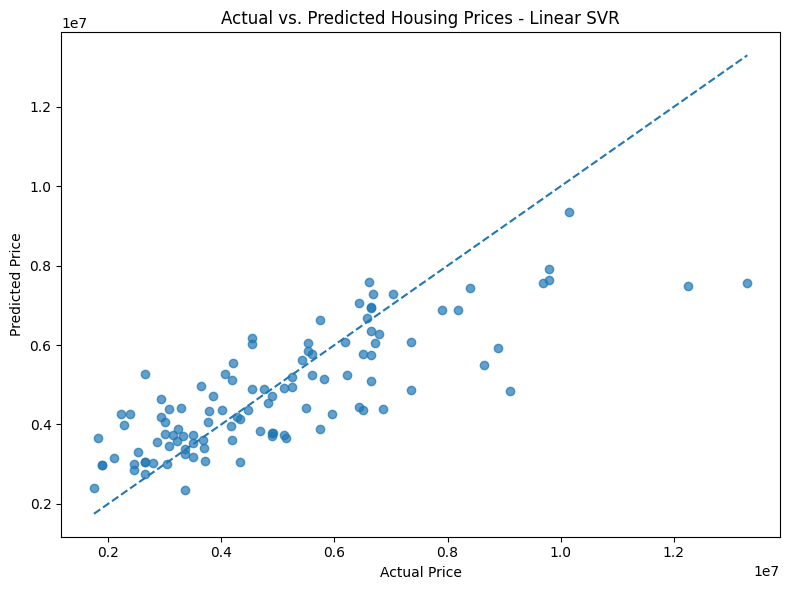

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)

# Ideal prediction line
min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Housing Prices - Linear SVR')

plt.tight_layout()
plt.show()

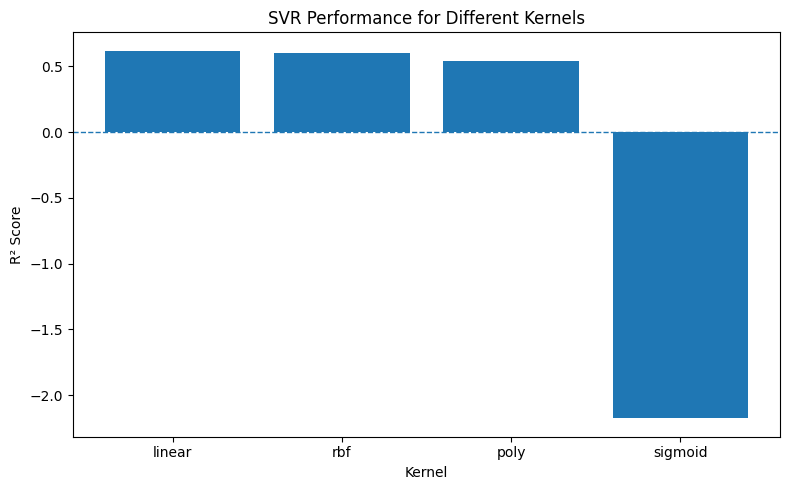

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df['Kernel'],
    results_df['R2']
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Kernel')
plt.ylabel('R² Score')
plt.title('SVR Performance for Different Kernels')

plt.tight_layout()
plt.show()

2.11 Regularized Linear Regression

In [13]:
# Create Ridge Regression model
ridge = Ridge(alpha=1.0)

# Train on the same scaled input features
ridge.fit(X_train_scaled, y_train)

# Predict housing prices
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluate
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"R²:   {r2_ridge:.4f}")
print(f"MAE:  {mae_ridge:,.2f}")
print(f"RMSE: {rmse_ridge:,.2f}")

R²:   0.6436
MAE:  979,146.94
RMSE: 1,342,156.00


In [14]:
comparison_df = results_df.copy()

comparison_df['Model'] = comparison_df['Kernel'].map({
    'linear': 'SVR - Linear',
    'rbf': 'SVR - RBF',
    'poly': 'SVR - Polynomial',
    'sigmoid': 'SVR - Sigmoid'
})

comparison_df = comparison_df[
    ['Model', 'R2', 'MAE', 'RMSE']
]

ridge_row = pd.DataFrame({
    'Model': ['Ridge Regression'],
    'R2': [r2_ridge],
    'MAE': [mae_ridge],
    'RMSE': [rmse_ridge]
})

comparison_df = pd.concat(
    [comparison_df, ridge_row],
    ignore_index=True
)

display(comparison_df)

,Model,R2,MAE,RMSE
0,SVR - Linear,0.617993,1.000478e+06,1.389562e+06
1,SVR - RBF,0.596951,1.049355e+06,1.427320e+06
2,SVR - Polynomial,0.541498,1.090739e+06,1.522343e+06
3,SVR - Sigmoid,-2.176916,2.607715e+06,4.007237e+06
4,Ridge Regression,0.643613,9.791469e+05,1.342156e+06


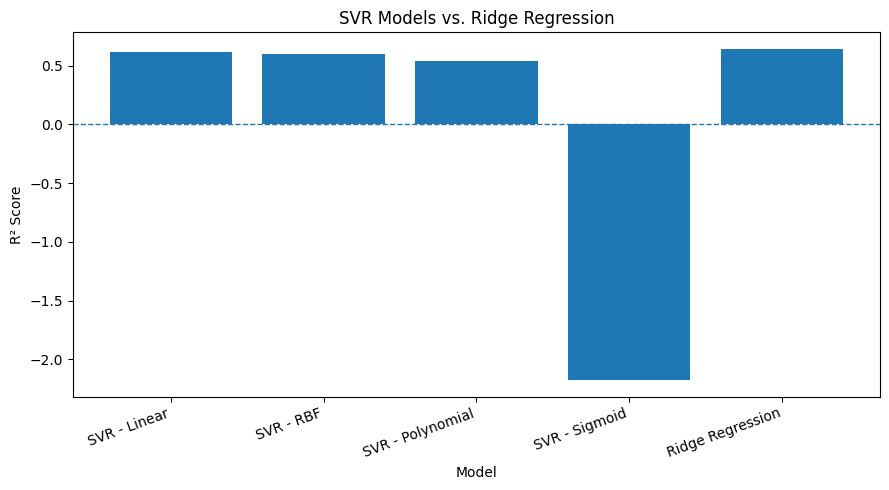

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df['Model'],
    comparison_df['R2']
)

plt.axhline(y=0, linestyle='--', linewidth=1)

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('SVR Models vs. Ridge Regression')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

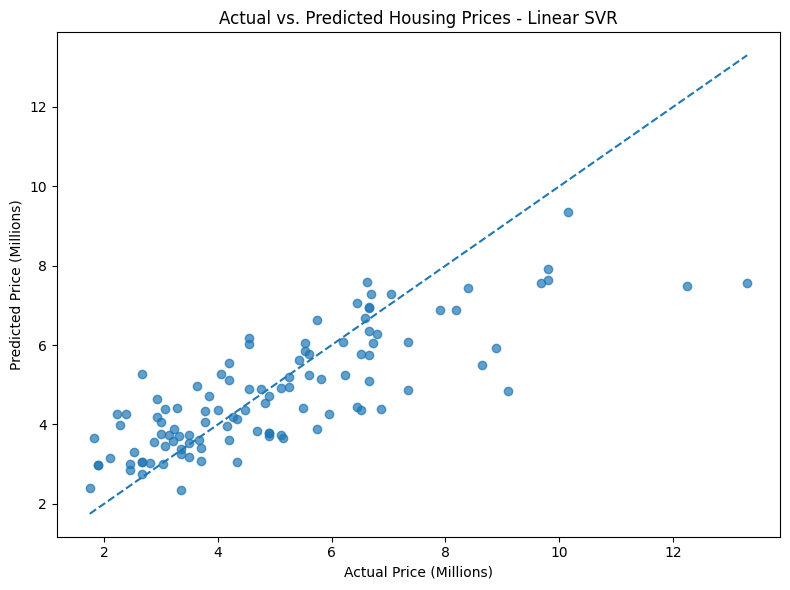

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test / 1e6,
    y_pred_linear / 1e6,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_linear.min()) / 1e6
max_price = max(y_test.max(), y_pred_linear.max()) / 1e6

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price (Millions)')
plt.ylabel('Predicted Price (Millions)')
plt.title('Actual vs. Predicted Housing Prices - Linear SVR')

plt.tight_layout()
plt.show()

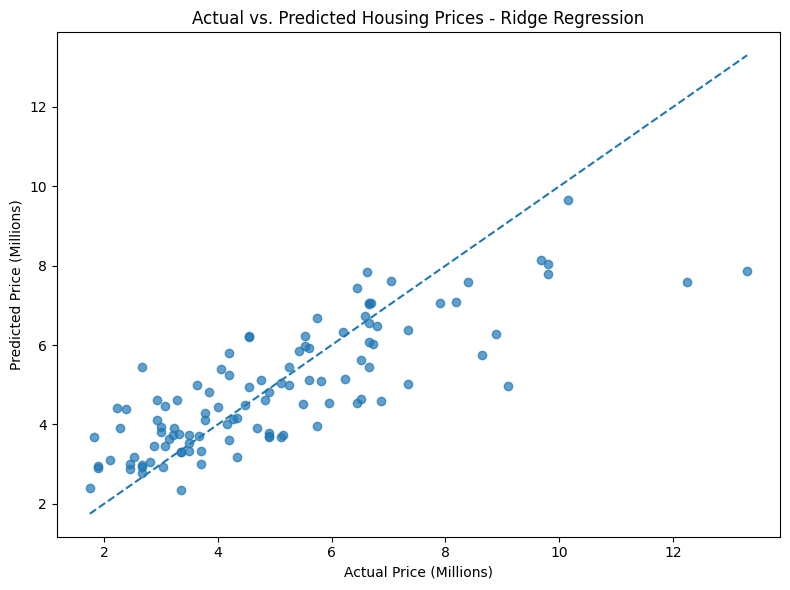

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test / 1e6,
    y_pred_ridge / 1e6,
    alpha=0.7
)

min_price = min(y_test.min(), y_pred_ridge.min()) / 1e6
max_price = max(y_test.max(), y_pred_ridge.max()) / 1e6

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price (Millions)')
plt.ylabel('Predicted Price (Millions)')
plt.title('Actual vs. Predicted Housing Prices - Ridge Regression')

plt.tight_layout()
plt.show()